In [1]:
import pandas as pd
import re
import spacy

from spacy.matcher import PhraseMatcher
from collections import Counter

In [2]:
df = pd.read_csv("clean_jobs_with_skills.csv")
print("Dataset shape:",df.shape)
print(df.columns.tolist())

Dataset shape: (7996, 18)
['company', 'education', 'experience', 'industry', 'jobdescription', 'jobid', 'joblocation_address', 'jobtitle', 'numberofpositions', 'payrate', 'postdate', 'site_name', 'skills', 'uniq_id', 'clean_description', 'original_length', 'clean_length', 'dictionary_skills']


In [3]:
taxonomy = pd.read_csv("skill_taxonomy.csv")
print("Taxonomy shape:", taxonomy.shape)
print(taxonomy.columns.tolist())
display(taxonomy.head(10))

Taxonomy shape: (101, 3)
['skill', 'category', 'aliases']


,skill,category,aliases
0,Python,Programming,python3|python
1,Java,Programming,java
2,C,Programming,c
3,C++,Programming,cpp|c plus plus
4,C#,Programming,csharp|c sharp
5,JavaScript,Programming,javascript|js
6,TypeScript,Programming,typescript|ts
7,R,Programming,r programming
8,HTML,Web Development,html|html5
9,CSS,Web Development,css|css3


In [4]:
taxonomy["skill"] = taxonomy["skill"].fillna("").astype(str)
taxonomy["category"] = taxonomy["category"].fillna("").astype(str)
taxonomy["aliases"] = taxonomy["aliases"].fillna("").astype(str)

taxonomy["skill"] = taxonomy["skill"].str.strip()
taxonomy["aliases"] = taxonomy["aliases"].str.strip()

# Create regrex patterns 

In [5]:
def create_regex_pattern(term):
    term = term.strip().lower()

    if not term:
        return None

    # Special cases
    if term == "c":
        return r"(?<![a-zA-Z])c(?![a-zA-Z0-9+#])"

    if term == "c++":
        return r"(?<![a-zA-Z0-9])c\+\+(?![a-zA-Z0-9])"

    if term == "c#":
        return r"(?<![a-zA-Z0-9])c#(?![a-zA-Z0-9])"

    # Normal terms
    escaped = re.escape(term)

    # Allow spaces / hyphens between words
    escaped = escaped.replace(r"\ ", r"[\s-]+")

    return r"(?<![a-zA-Z0-9])" + escaped + r"(?![a-zA-Z0-9])"

# create skill patterns

In [6]:
skill_patterns = {}

for _, row in taxonomy.iterrows():

    skill = row["skill"]

    if not skill:
        continue

    terms = [skill]

    # Add aliases
    if row["aliases"] and row["aliases"].lower() != "nan":
        aliases = row["aliases"].split(",")

        for alias in aliases:
            alias = alias.strip()

            if alias:
                terms.append(alias)

    skill_patterns[skill] = terms

In [7]:
for skill, terms in list(skill_patterns.items())[:10]:
    print(skill, "->", terms)

Python -> ['Python', 'python3|python']
Java -> ['Java', 'java']
C -> ['C', 'c']
C++ -> ['C++', 'cpp|c plus plus']
C# -> ['C#', 'csharp|c sharp']
JavaScript -> ['JavaScript', 'javascript|js']
TypeScript -> ['TypeScript', 'typescript|ts']
R -> ['R', 'r programming']
HTML -> ['HTML', 'html|html5']
CSS -> ['CSS', 'css|css3']


# create extractor

In [8]:
def regex_extract_skills(text):

    found = []

    if pd.isna(text):
        return found

    text = str(text)

    for skill, terms in skill_patterns.items():

        for term in terms:

            pattern = create_regex_pattern(term)

            if pattern and re.search(pattern, text, re.IGNORECASE):

                found.append(skill)
                break

    return list(dict.fromkeys(found))

In [9]:
test_text = """
We are looking for a Python 3 developer.
The candidate should know Python3, SQL,
Power BI, AWS, Excel and PostgreSQL.
Experience in machine learning is preferred.
"""
print(regex_extract_skills(test_text))

['Python', 'SQL', 'PostgreSQL', 'Power BI', 'Excel', 'AWS', 'Machine Learning']


In [10]:
nlp = spacy.blank("en")

print("spaCy model loaded successfully!")

spaCy model loaded successfully!


In [11]:
phrase_skill_map = {}

for _, row in taxonomy.iterrows():

    skill = row["skill"]

    if not skill:
        continue

    # Main skill
    phrase_skill_map[skill.lower()] = skill

    # Aliases
    if row["aliases"] and row["aliases"].lower() != "nan":

        aliases = row["aliases"].split(",")

        for alias in aliases:

            alias = alias.strip().lower()

            if alias:
                phrase_skill_map[alias] = skill

In [12]:
matcher = PhraseMatcher(nlp.vocab,attr="LOWER")
phrase_patterns=[]
phrase_names=[]
for phrase,skill in phrase_skill_map.items():

    # skip very short terms
    if len(phrase)>= 2:
        pattern = nlp.make_doc(phrase)  
        matcher.add(skill,[pattern])

print("phrase patterns:",len(phrase_patterns))
   


phrase patterns: 0


# Create SpaCy Phrase extractor

In [13]:
def phrase_extract_skills(text):

    found = []

    if pd.isna(text):
        return found

    doc = nlp(str(text))

    matches = matcher(doc)

    for match_id, start, end in matches:

        skill = nlp.vocab.strings[match_id]

        if skill not in found:
            found.append(skill)

    return found

In [14]:
test_text = """
The candidate should have experience in
machine learning, deep learning, data science,
natural language processing and customer service.
"""

print(phrase_extract_skills(test_text))

['Machine Learning', 'Deep Learning', 'Data Science', 'Natural Language Processing', 'Customer Service']


# combine Regex + spaCY

In [15]:
def advanced_extract_skills(text):

    if pd.isna(text):
        return []

    # Regex
    regex_skills = regex_extract_skills(text)

    # spaCy Phrase Matching
    phrase_skills = phrase_extract_skills(text)

    # Combine
    all_skills = regex_skills + phrase_skills

    # Remove duplicates
    all_skills = list(dict.fromkeys(all_skills))

    return all_skills

In [16]:
test_text = """
We are looking for a Python 3 developer
with experience in SQL, AWS, Power BI,
machine learning and data science.
"""

result = advanced_extract_skills(test_text)

print("Extracted Skills:")
print(result)

Extracted Skills:
['Python', 'SQL', 'Power BI', 'AWS', 'Machine Learning', 'Data Science']


In [17]:
text = df["clean_description"].iloc[0]

print(text)


job description send me jobs like this qualifications 10th to graduation any skill basic computer knowledge job requirement system or laptop type of job full time or part time languages tamil english experience freshers experience payment details 1 form per day 5 10 form per day 50 100 form per day 500 monthly you can earn 15000 per month selection process easy selection process so what are you waiting for apply now grab best opportunity to make your carrier to improve your earing skills more detail contact mr hari salary inr 1 50 000 2 25 000 p a industry media entertainment internet functional area ites bpo kpo lpo customer service operations role category other role fresher keyskills english typing part time data entry selection process desired candidate profile education ug b tech b e any specialization pg any postgraduate any specialization post graduation not required please refer to the job description above company profile mm media pvt ltd mass media international find live inf

In [18]:
result = advanced_extract_skills(text)
print("Extracted SKills")
print(result)

Extracted SKills
['Basic Computer Knowledge', 'Internet', 'Data Entry', 'Typing', 'English Typing', 'Data Collection', 'Customer Service', 'BPO', 'KPO', 'Operations', 'English', 'Tamil']


In [19]:
df["regex_Phrase_skills"] = df["clean_description"].apply(
    advanced_extract_skills
)

In [20]:
df[["clean_description", "regex_Phrase_skills"]].head()

,clean_description,regex_Phrase_skills
0,job description send me jobs like this qualifi...,"[Basic Computer Knowledge, Internet, Data Entr..."
1,job description send me jobs like this qualifi...,"[Basic Computer Knowledge, Data Entry, Data Co..."
2,job description send me jobs like this as a de...,[SQL]
3,job description send me jobs like this involve...,[C]
4,job description send me jobs like this please ...,"[Java, JavaScript, HTML, Angular, MySQL, Git]"


In [23]:
df.to_csv("clean_jobs_with_skills.csv", index=False)

In [24]:
print(df.columns.tolist())

['company', 'education', 'experience', 'industry', 'jobdescription', 'jobid', 'joblocation_address', 'jobtitle', 'numberofpositions', 'payrate', 'postdate', 'site_name', 'skills', 'uniq_id', 'clean_description', 'original_length', 'clean_length', 'dictionary_skills', 'regex_Phrase_skills']


# count extracted skills

In [24]:
all_skills = []

for skills in df["regex_Phrase_skills"]:

    all_skills.extend(skills)

skill_counts = Counter(all_skills)

print("Top 20 Extracted Skills:")

for skill, count in skill_counts.most_common(20):

    print(skill, ":", count)

Top 20 Extracted Skills:
Communication : 2934
Operations : 1635
Java : 979
C : 970
BPO : 933
Customer Service : 930
SQL : 889
English : 720
KPO : 705
R : 663
Internet : 628
Oracle : 614
Call Center : 588
JavaScript : 562
HTML : 415
Excel : 406
CSS : 331
MS Office : 311
Computer Vision : 293
php : 237


# create skill count dataframe

In [25]:
skill_count_df = pd.DataFrame(
    skill_counts.most_common(),
    columns=["skill", "job_count"]
)

display(skill_count_df.head(20))

,skill,job_count
0,Communication,2934
1,Operations,1635
2,Java,979
3,C,970
4,BPO,933
5,Customer Service,930
6,SQL,889
7,English,720
8,KPO,705
9,R,663


# visualization

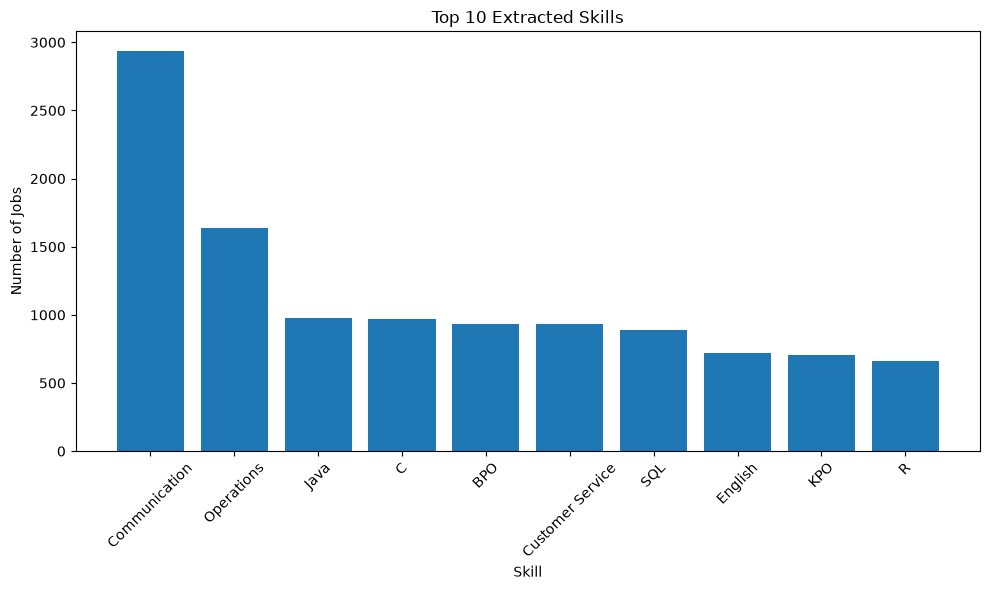

In [26]:
import matplotlib.pyplot as plt

top_10 = skill_count_df.head(10)

plt.figure(figsize=(10, 6))

plt.bar(
    top_10["skill"],
    top_10["job_count"]
)

plt.title("Top 10 Extracted Skills")
plt.xlabel("Skill")
plt.ylabel("Number of Jobs")

plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig(
    "top_10_advanced_skills.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()